In [10]:
import json

def load_json(path):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            return data
    except FileNotFoundError:
        print("Файл не найден")
    except json.JSONDecodeError as e:
        print(f"Ошибка в формате JSON: {e}")


j = load_json("/mnt/external_usb_hdd/6YL/Datasets/3RScan/files/3RScan.json")


'00d42bed-778d-2ac6-86a7-0e0e5f5f5660'

In [11]:
import os

print(os.path.join("/mnt/external_usb_hdd/6YL/Datasets/3RScan/files", '3RScan.json'))

/mnt/external_usb_hdd/6YL/Datasets/3RScan/files/3RScan.json


In [17]:

import os
import json
import torch
import faiss
import logging
import numpy as np
from glob import glob
from tqdm import tqdm
from PIL import Image
from os.path import join
import torch.utils.data as data
import torchvision.transforms as transforms
from torch.utils.data.dataset import Subset
from sklearn.neighbors import NearestNeighbors
from torch.utils.data.dataloader import DataLoader

from scipy.spatial.distance import pdist
import math

base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def path_to_pil_img(path):
    return Image.open(path).convert("RGB")


def load_json(path):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            return data
    except FileNotFoundError:
        print("Файл не найден")
    except json.JSONDecodeError as e:
        print(f"Ошибка в формате JSON: {e}")


def collate_fn(batch):
    """Creates mini-batch tensors from the list of tuples (images, 
        triplets_local_indexes, triplets_global_indexes).
        triplets_local_indexes are the indexes referring to each triplet within images.
        triplets_global_indexes are the global indexes of each image.
    Args:
        batch: list of tuple (images, triplets_local_indexes, triplets_global_indexes).
            considering each query to have 10 negatives (negs_num_per_query=10):
            - images: torch tensor of shape (12, 3, h, w).
            - triplets_local_indexes: torch tensor of shape (10, 3).
            - triplets_global_indexes: torch tensor of shape (12).
    Returns:
        images: torch tensor of shape (batch_size*12, 3, h, w).
        triplets_local_indexes: torch tensor of shape (batch_size*10, 3).
        triplets_global_indexes: torch tensor of shape (batch_size, 12).
    """
    images                  = torch.cat([e[0] for e in batch])
    triplets_local_indexes  = torch.cat([e[1][None] for e in batch])
    triplets_global_indexes = torch.cat([e[2][None] for e in batch])
    for i, (local_indexes, global_indexes) in enumerate(zip(triplets_local_indexes, triplets_global_indexes)):
        local_indexes += len(global_indexes) * i  # Increment local indexes by offset (len(global_indexes) is 12)
    return images, torch.cat(tuple(triplets_local_indexes)), triplets_global_indexes


def extract_sequence_id(path):



class PCADataset(data.Dataset):
    def __init__(self, args, datasets_folder="dataset", dataset_folder="pitts30k/images/train"):
        dataset_folder_full_path = join(datasets_folder, dataset_folder)
        if not os.path.exists(dataset_folder_full_path) :
            raise FileNotFoundError(f"Folder {dataset_folder_full_path} does not exist")
        self.images_paths = sorted(glob(join(dataset_folder_full_path, "**", "*.jpg"), recursive=True))
    def __getitem__(self, index):
        return base_transform(path_to_pil_img(self.images_paths[index]))
    def __len__(self):
        return len(self.images_paths)

def make_item(img_path, graph_path=None, scene=None, pose=None):
    return {"img": img_path, "graph": graph_path, "scene": scene, "pose": pose}

class BaseDataset(data.Dataset):
    """Dataset with images from database and queries, used for inference (testing and building cache).
    """
    def __init__(self, args, datasets_folder="datasets", dataset_name="3RScan", split="train"):
        super().__init__()
        #self.args = args
        #self.modalites = args.modalites
        self.dataset_name = dataset_name
        self.dataset_folder = join(datasets_folder, dataset_name)
        if not os.path.exists(self.dataset_folder): raise FileNotFoundError(f"Folder {self.dataset_folder} does not exist")
        
        #self.resize = args.resize
        #self.test_method = args.test_method

        database_folder = []
        queries_folder  = []
        #### Read paths and UTM coordinates for all images.

        if 'graph' in self.modalites:
            all_graph_paths = sorted(glob(join(self.files_root, "**", "*.pt"), recursive=True))
        if 'image' in self.modelites:
            all_image_paths = glob(os.path.join(folder, "**", "*.color.jpg"), recursive=True)


        seq_to_image_paths = defaultdict(list)
        for p in all_image_paths:
            seq = extract_sequence_id(p)
            seq_to_image_paths[seq].append(p)

        if dataset_name == "3RScan":
            meta_data = join(self.dataset_folder, 'files')
            scene_data = join(meta_data, '3RScan.json')

            if split == 'train':
                train_scans = join(meta_data, "train_scans.txt")
                with open(train_scans, 'r', encoding='utf-8') as file:
                    for line in file:
                        scene_name = line.strip()
                        if scene_name:
                            items = []
                            
                            if 'graph' in self.modalites:
                                scene_path = join(self.dataset_folder, "Splited_graphs", scene_name)
                                all_graph_paths = sorted(glob(join(scene_path, "**", "*.pt"), recursive=True))

                                
                            


        if not os.path.exists(database_folder): raise FileNotFoundError(f"Folder {database_folder} does not exist")
        if not os.path.exists(queries_folder) : raise FileNotFoundError(f"Folder {queries_folder} does not exist")
        self.database_paths = sorted(glob(join(database_folder, "**", "*.jpg"), recursive=True))
        self.queries_paths  = sorted(glob(join(queries_folder, "**", "*.jpg"),  recursive=True))
        # The format must be path/to/file/@utm_easting@utm_northing@...@.jpg
        self.database_utms = np.array([(path.split("@")[1], path.split("@")[2]) for path in self.database_paths]).astype(np.float)
        self.queries_utms  = np.array([(path.split("@")[1], path.split("@")[2]) for path in self.queries_paths]).astype(np.float)
        
        # Find soft_positives_per_query, which are within val_positive_dist_threshold (deafult 25 meters)
        knn = NearestNeighbors(n_jobs=-1)
        knn.fit(self.database_utms)
        if split=="train":
            self.soft_positives_per_query = knn.radius_neighbors(self.queries_utms, 
                                                                radius=25,
                                                                return_distance=False)
        else:
            self.soft_positives_per_query = knn.radius_neighbors(self.queries_utms, 
                                                                args.val_positive_dist_threshold,
                                                                return_distance=False)            
        self.images_paths = list(self.database_paths) + list(self.queries_paths)
        
        self.database_num = len(self.database_paths)
        self.queries_num  = len(self.queries_paths)
    
    def __getitem__(self, index):
        img = path_to_pil_img(self.images_paths[index])
        img = base_transform(img)
        # With database images self.test_method should always be "hard_resize"
        if self.test_method == "hard_resize":
            # self.test_method=="hard_resize" is the default, resizes all images to the same size.
            img = transforms.functional.resize(img, self.resize)
        else:
            img = self._test_query_transform(img)
        return img, index
    


    def _test_query_transform(self, img):
        """Transform query image according to self.test_method."""
        C, H, W = img.shape
        if self.test_method == "single_query":
            # self.test_method=="single_query" is used when queries have varying sizes, and can't be stacked in a batch.
            processed_img = transforms.functional.resize(img, min(self.resize))
        elif self.test_method == "central_crop":
            # Take the biggest central crop of size self.resize. Preserves ratio.
            scale = max(self.resize[0]/H, self.resize[1]/W)
            processed_img = torch.nn.functional.interpolate(img.unsqueeze(0), scale_factor=scale).squeeze(0)
            processed_img = transforms.functional.center_crop(processed_img, self.resize)
            assert processed_img.shape[1:] == torch.Size(self.resize), f"{processed_img.shape[1:]} {self.resize}"
        elif self.test_method == "five_crops" or self.test_method == 'nearest_crop' or self.test_method == 'maj_voting':
            # Get 5 square crops with size==shorter_side (usually 480). Preserves ratio and allows batches.
            shorter_side = min(self.resize)
            processed_img = transforms.functional.resize(img, shorter_side)
            processed_img = torch.stack(transforms.functional.five_crop(processed_img, shorter_side))
            assert processed_img.shape == torch.Size([5, 3, shorter_side, shorter_side]), \
                f"{processed_img.shape} {torch.Size([5, 3, shorter_side, shorter_side])}"
        return processed_img
    
    def __len__(self):
        return len(self.images_paths)
    def __repr__(self):
        return  (f"< {self.__class__.__name__}, {self.dataset_name} - #database: {self.database_num}; #queries: {self.queries_num} >")
    def get_positives(self):
        return self.soft_positives_per_query


database = BaseDataset(None, datasets_folder = "/mnt/external_usb_hdd/6YL/Datasets")

02b33dfb-be2b-2d54-92d2-cd012b2b3c40
02b33e01-be2b-2d54-93fb-4145a709cec5
0958220d-e2c2-2de1-9710-c37018da1883
09582212-e2c2-2de1-9700-fa44b14fbded
09582225-e2c2-2de1-9564-f6681ef5e511
09582244-e2c2-2de1-956c-357092d949d1
0958224e-e2c2-2de1-943b-38e36345e2e7
0ad2d382-79e2-2212-98b3-641bf9d552c1
0ad2d386-79e2-2212-9b40-43d081db442a
0ad2d38f-79e2-2212-98d2-9b5060e5e9b5
0ad2d399-79e2-2212-99cf-7a3512734bd7
0ad2d39b-79e2-2212-99ae-830c292cd079
0ad2d3a3-79e2-2212-9a51-9094be707ec2
0cac7536-8d6f-2d13-8dc2-2f9d7aa62dc4
0cac753c-8d6f-2d13-8e27-e0664fc33bb9
0cac7549-8d6f-2d13-8d56-b895956f571a
0cac7558-8d6f-2d13-8fe1-c8af0362735d
0cac755a-8d6f-2d13-8fed-b1be02f4ef77
0cac755e-8d6f-2d13-8c6a-c0979ca34a4f
0cac7564-8d6f-2d13-8cb2-8b01c0a1b3d5
0cac7574-8d6f-2d13-8db6-4304f437e6d5
0cac7578-8d6f-2d13-8c2d-bfa7a04f8af3
0cac7580-8d6f-2d13-8c9d-d45247b5244b
0cac7597-8d6f-2d13-8c9c-6f8542021d5c
0cac759b-8d6f-2d13-8e3b-2e3bc1ee1158
0cac75a7-8d6f-2d13-8fdc-083ff44d10fb
0cac75ad-8d6f-2d13-8c74-5de4dfc4affc
0

TypeError: stat: path should be string, bytes, os.PathLike or integer, not list

In [ ]:
#!/usr/bin/env python3
"""
export_poses_to_csv.py

Scan a sequence folder (or sequence.zip) for per-frame pose files (e.g. frame-000000.pose.txt),
parse 4x4 pose matrices, compute translation t and camera center candidates, and export CSV.

Produces CSV with columns:
frame, t_x, t_y, t_z, cam_x, cam_y, cam_z, detR, norm_t, norm_cam

Usage:
  # folder with many frame-*.pose.txt
  python export_poses_to_csv.py --input /path/to/sequence_folder --out poses.csv

  # directly read from sequence.zip
  python export_poses_to_csv.py --input /path/to/sequence.zip --out poses.csv

Notes:
 - The parser accepts both "4 lines of 4 numbers" and single-line 16 floats (row-major).
 - If matrix is M, we assume layout:
      [ R11 R12 R13 tx
        R21 R22 R23 ty
        R31 R32 R33 tz
        0    0    0   1 ]
   then t = [tx,ty,tz]; and camera center candidate if M == world->camera is cam = -R.T @ t.
"""
import os
import sys
import argparse
import csv
import io
import math
from zipfile import ZipFile
import numpy as np
from glob import glob

def parse_pose_text(text):
    """
    Parse text containing 4x4 matrix. Accepts:
      - 4 lines of 4 floats each
      - 1 line (or any) with >=16 floats (will take first 16, row-major)
    Returns 4x4 numpy array.
    """
    # split into tokens
    toks = []
    for line in text.splitlines():
        parts = line.strip().split()
        if len(parts) == 0:
            continue
        for p in parts:
            toks.append(p)
    # try floats
    try:
        vals = [float(x) for x in toks]
    except Exception as e:
        raise ValueError(f"Cannot parse floats from pose text: {e}")

    if len(vals) >= 16:
        arr = np.array(vals[:16], dtype=float).reshape((4,4))
        return arr
    else:
        raise ValueError(f"Pose text contains fewer than 16 numbers ({len(vals)})")

def process_pose_matrix(M):
    """Given 4x4 matrix M -> return t (3,), cam_center (3,), detR, norms"""
    if M.shape != (4,4):
        raise ValueError("M must be 4x4")
    R = M[:3,:3]
    t = M[:3,3]
    detR = float(np.linalg.det(R))
    cam_center = -R.T.dot(t)   # if M is world->camera, this gives camera center in world
    norm_t = float(np.linalg.norm(t))
    norm_cam = float(np.linalg.norm(cam_center))
    return t, cam_center, detR, norm_t, norm_cam

def find_pose_files_in_folder(folder):
    # common patterns: frame-*.pose.txt, *.pose.txt, *.pose
    patterns = ["**/frame-*.pose.txt", "**/*.pose.txt", "**/*.pose"]
    files = []
    for p in patterns:
        files.extend(glob(os.path.join(folder, p), recursive=True))
    files = sorted(list(set(files)))
    return files

def read_file_from_zip(zip_path, inner_path):
    with ZipFile(zip_path, 'r') as z:
        with z.open(inner_path) as f:
            raw = f.read().decode('utf-8')
            return raw

def list_pose_files_in_zip(zip_path):
    with ZipFile(zip_path, 'r') as z:
        # pick files that endwith .pose.txt or .pose
        candidates = [n for n in z.namelist() if n.lower().endswith('.pose.txt') or n.lower().endswith('.pose')]
        # try to filter to frame- prefix presence first
        frame_like = [n for n in candidates if os.path.basename(n).lower().startswith('frame')]
        if len(frame_like) > 0:
            return sorted(frame_like)
        return sorted(candidates)

def main(args):
    input_path = args.input
    out_csv = args.out
    items = []  # tuples (frame_name, t, cam, detR, norm_t, norm_cam)

    if os.path.isdir(input_path):
        pose_files = find_pose_files_in_folder(input_path)
        if len(pose_files) == 0:
            print(f"No pose files found in folder {input_path}. Tried patterns like frame-*.pose.txt and *.pose.txt", file=sys.stderr)
            sys.exit(1)
        for pf in pose_files:
            try:
                with open(pf, 'r') as f:
                    text = f.read()
                M = parse_pose_text(text)
                t, cam_center, detR, norm_t, norm_cam = process_pose_matrix(M)
                frame_name = os.path.relpath(pf, input_path)
                items.append((frame_name, t, cam_center, detR, norm_t, norm_cam))
            except Exception as e:
                print(f"Warning: failed to parse {pf}: {e}", file=sys.stderr)
    elif os.path.isfile(input_path) and input_path.lower().endswith('.zip'):
        zip_path = input_path
        pose_list = list_pose_files_in_zip(zip_path)
        if len(pose_list) == 0:
            print(f"No pose files found inside zip {zip_path}", file=sys.stderr)
            sys.exit(1)
        for inner in pose_list:
            try:
                txt = read_file_from_zip(zip_path, inner)
                M = parse_pose_text(txt)
                t, cam_center, detR, norm_t, norm_cam = process_pose_matrix(M)
                frame_name = inner
                items.append((frame_name, t, cam_center, detR, norm_t, norm_cam))
            except Exception as e:
                print(f"Warning: failed to parse {inner} inside zip: {e}", file=sys.stderr)
    else:
        print("Input must be a directory with pose files or a sequence.zip file", file=sys.stderr)
        sys.exit(1)

    # write CSV
    header = ["frame", "t_x", "t_y", "t_z", "cam_x", "cam_y", "cam_z", "detR", "norm_t", "norm_cam"]
    with open(out_csv, 'w', newline='') as csvf:
        writer = csv.writer(csvf)
        writer.writerow(header)
        for frame_name, t, cam_center, detR, norm_t, norm_cam in items:
            writer.writerow([frame_name,
                             float(t[0]), float(t[1]), float(t[2]),
                             float(cam_center[0]), float(cam_center[1]), float(cam_center[2]),
                             detR, norm_t, norm_cam])

    print(f"Wrote {len(items)} poses to {out_csv}")

    # print quick summary statistics to help pick which candidate to use
    t_norms = np.array([it[4] for it in items])
    cam_norms = np.array([it[5] for it in items])

    def summarize(name, arr):
        return {
            "count": int(len(arr)),
            "min": float(np.min(arr)),
            "max": float(np.max(arr)),
            "mean": float(np.mean(arr)),
            "std": float(np.std(arr))
        }
    print("Summary (norms):")
    print(" t (last column) :", summarize("t", t_norms))
    print(" cam_center (inv) :", summarize("cam", cam_norms))

    # heuristic suggestion
    # If one candidate has much larger spread / mean, likely that's world coords
    mean_t = float(np.mean(t_norms))
    mean_cam = float(np.mean(cam_norms))
    range_t = float(np.max(t_norms) - np.min(t_norms))
    range_cam = float(np.max(cam_norms) - np.min(cam_norms))
    print("\nHeuristic suggestion:")
    if range_t > range_cam * 2:
        print(" - The direct translation t shows a larger spatial spread — likely t is camera center in world (use t).")
    elif range_cam > range_t * 2:
        print(" - The inverted camera_center shows a larger spread — likely you should use camera_center = -R.T @ t (use cam_center).")
    else:
        print(" - Both candidates have comparable spread. Inspect the CSV visually or test projection with intrinsics to be sure.")

if __name__ == "__main__":
    p = argparse.ArgumentParser()
    p.add_argument("--input", required=True, help="Path to unpacked sequence folder (contains frame-*.pose.txt) or sequence.zip")
    p.add_argument("--out", required=True, help="Output CSV file path, e.g. poses.csv")
    args = p.parse_args()
    main(args)

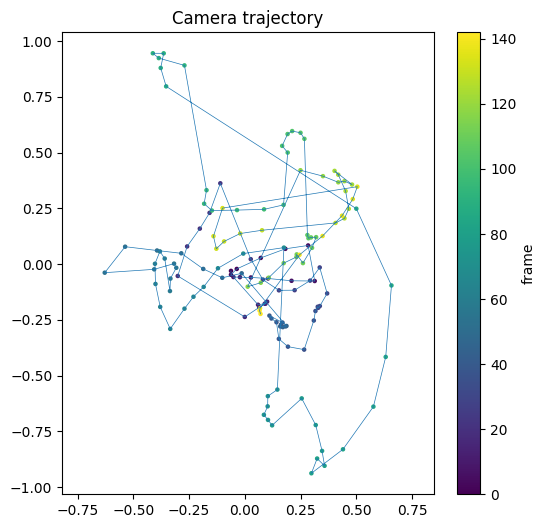

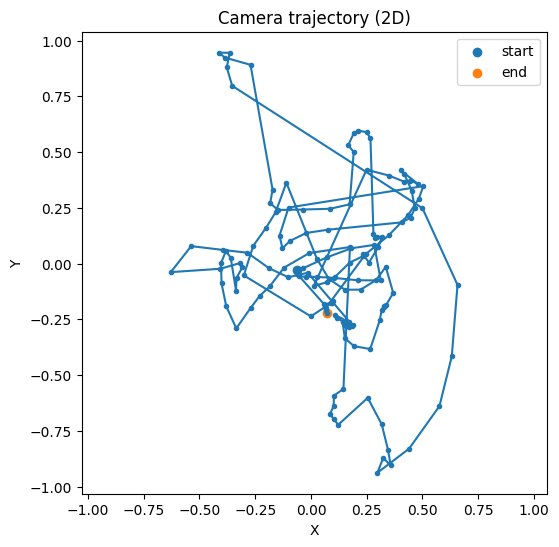

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Путь к распакованной sequence
sequence_path = Path("/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence")

pose_files = sorted(sequence_path.glob("**/frame-*.pose.txt"))

poses = []


for f in pose_files:
    M = np.loadtxt(f)
    R = M[:3,:3]
    t = M[:3,3]
    cam_center = -R.T @ t
    poses.append(cam_center)

poses = np.array(poses)

x = poses[:,0]
y = poses[:,1]

plt.figure(figsize=(6,6))

plt.scatter(x, y, c=np.arange(len(x)), cmap="viridis", s=5)
plt.plot(x, y, linewidth=0.5)

plt.colorbar(label="frame")
plt.axis("equal")
plt.title("Camera trajectory")
plt.show()
plt.figure(figsize=(6,6))
plt.plot(x, y, marker="o", markersize=3)
plt.scatter(x[0], y[0], label="start")
plt.scatter(x[-1], y[-1], label="end")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Camera trajectory (2D)")
plt.axis("equal")
plt.legend()
plt.show()

In [5]:
import numpy as np

# -------------------------
# Утилиты: parse / reshape
# -------------------------
def mat_from_flat_list(flat16):
    """
    Принимает list/array из 16 чисел (как в JSON) и возвращает 4x4 numpy matrix.
    3RScan хранит трансформы column-major flattened, поэтому используем order='F'.
    """
    arr = np.array(flat16, dtype=float)
    if arr.size != 16:
        raise ValueError("Expected 16 numbers")
    M = arr.reshape((4,4), order='F')   # column-major -> обычная 4x4 матрица
    return M

def is_valid_homogeneous(M, atol=1e-6):
    """Проверка: нижняя строка должна быть [0,0,0,1] (или близко к ней)."""
    return np.allclose(M[3,:], np.array([0,0,0,1]), atol=atol)

def rotation_and_translation(M):
    R = M[:3,:3]
    t = M[:3,3]
    return R, t

def inv_transform(M):
    """Инвертирование 4x4 трансформации: M^{-1} = [R^T, -R^T t; 0 1]"""
    R, t = rotation_and_translation(M)
    Rinv = R.T
    tinv = -Rinv @ t
    Minv = np.eye(4, dtype=M.dtype)
    Minv[:3,:3] = Rinv
    Minv[:3,3] = tinv
    return Minv

# -------------------------
# Применение трансформации
# -------------------------
def apply_transform_to_points(M, points):
    """
    points: (N,3) array or list of points.
    Возвращает преобразованные точки в однородной форме: x' = M @ [x,1].
    """
    pts = np.asarray(points, dtype=float)
    if pts.ndim == 1:
        pts = pts.reshape(1,3)
    ones = np.ones((pts.shape[0],1), dtype=float)
    hom = np.concatenate([pts, ones], axis=1)   # (N,4)
    transformed = (M @ hom.T).T                 # (N,4)
    return transformed[:,:3]

def apply_transform_to_pose(M_transform, pose):
    """
    Приведение pose (4x4) при помощи M_transform:
      pose_new = M_transform @ pose
    Возвращает 4x4.
    """
    return M_transform @ pose

{'ambiguity': [], 'reference': '02b33dfb-be2b-2d54-92d2-cd012b2b3c40', 'scans': [{'nonrigid': [], 'reference': 'fcf66d9e-622d-291c-84c2-bb23dfe31327', 'removed': [], 'rigid': [{'instance_reference': 30, 'instance_rescan': 30, 'symmetry': 0, 'transform': [0.7864626049995422, -0.6136088371276855, 0.07043170928955078, 0, 0.6176229119300842, 0.7821053862571716, -0.08278355747461319, 0, -0.004288293421268463, 0.10860642045736313, 0.9940755367279053, 0, -0.015237279236316681, 0.2942926287651062, 0.08408773690462112, 1]}, {'instance_reference': 12, 'instance_rescan': 12, 'symmetry': 0, 'transform': [0.7987864017486572, -0.5980721712112427, -0.06519106030464172, 0, 0.599686861038208, 0.800206184387207, 0.00675886170938611, 0, 0.048124004155397415, -0.04449310898780823, 0.9978498816490173, 0, 0.05569322407245636, 0.08721847832202911, -0.06248684972524643, 1]}, {'instance_reference': 27, 'instance_rescan': 27, 'symmetry': 0, 'transform': [0.7446263432502747, -0.6095316410064697, 0.27203387022018

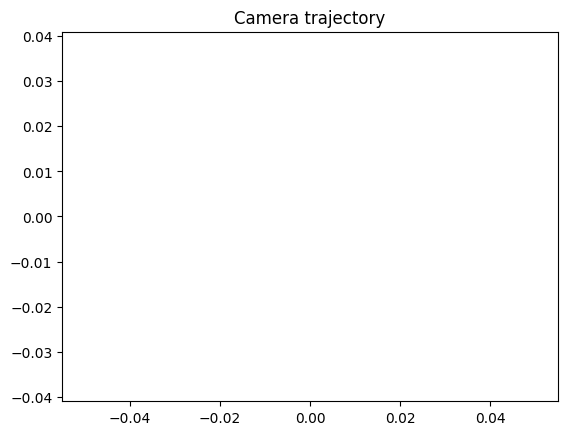

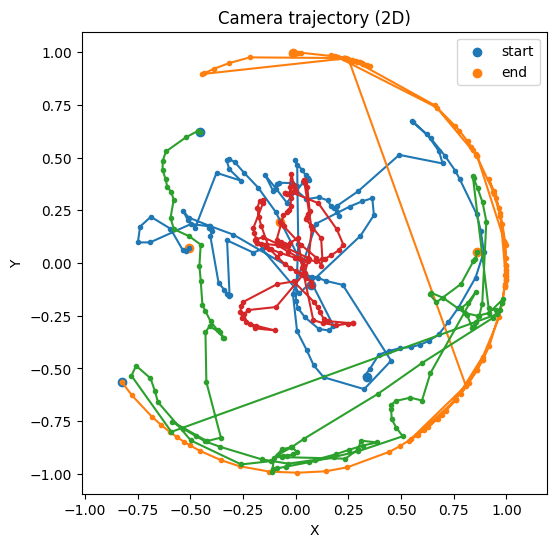

In [7]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# load meta json (3RScan meta)
meta = json.load(open("/mnt/external_usb_hdd/6YL/Datasets/3RScan/files/3RScan.json"))   # или нужный объект из списка -> найти нужный scan entry

# for example, take first scans entry inside first top-level item:
item = meta[1]
print(item)
# item['scans'] is a list of rescans; pick one:
scan_entry = item['scans'][0]
scan_transform_flat = scan_entry['transform']   # flat list of 16 numbers
print( item['scans'])
print(scan_transform_flat)
T = mat_from_flat_list(scan_transform_flat)

# load per-frame poses for that rescan (folder)
pose_files = sorted(Path("/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/fcf66d9e-622d-291c-84c2-bb23dfe31327/sequence").glob("**/frame-*.pose.txt"))
poses = []
for f in pose_files:
    M = np.loadtxt(str(f)).reshape((4,4))  # если pose files row-major & already in correct order
    # Note: if pose files are saved in row-major text (4 rows x 4 cols), this works.
    poses.append(M)

poses_in_ref = [apply_transform_to_pose(T, p) for p in poses]



poses_in_ref = np.array(poses_in_ref)

x = poses_in_ref[:,0]
y = poses_in_ref[:,1]

plt.axis("equal")
plt.title("Camera trajectory")
plt.show()
plt.figure(figsize=(6,6))
plt.plot(x, y, marker="o", markersize=3)
plt.scatter(x[0], y[0], label="start")
plt.scatter(x[-1], y[-1], label="end")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Camera trajectory (2D)")
plt.axis("equal")
plt.legend()
plt.show()

T translation (from JSON transform): [ 0.09012863 -0.09965667  0.009489  ]
T_inv translation: [-0.01145749  0.13390323 -0.00912781]
det(R) of T: 1.0000001256268498
Found 143 pose files, example: frame-000000.pose.txt
t_raw: n=143  norm_min=0.062 mean=0.481 max=1.035
cam_raw: n=143  norm_min=0.062 mean=0.481 max=1.035
t_T: n=143  norm_min=0.131 mean=0.556 max=1.162
cam_T: n=143  norm_min=0.131 mean=0.556 max=1.162
t_Tinv: n=143  norm_min=0.065 mean=0.458 max=0.930
cam_Tinv: n=143  norm_min=0.065 mean=0.458 max=0.930
sample translations (first 5) t_raw:
 [[-0.0434051  0.0326288 -0.137367 ]
 [-0.0607319  0.0219067 -0.125337 ]
 [-0.027458   0.0117298 -0.0540599]
 [ 0.034138  -0.0160679  0.0781452]
 [ 0.0902946 -0.053168   0.179408 ]]
sample cam centers (first 5) cam_raw:
 [[-0.06231156 -0.03042325 -0.1304225 ]
 [-0.06242597 -0.04779057 -0.11703292]
 [-0.03645189 -0.02167345 -0.04489458]
 [ 0.07117893  0.02771048  0.0411818 ]
 [ 0.18142851  0.06847556  0.07457852]]
sample transformed (T) t_

/tmp/ipykernel_504505/212615226.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


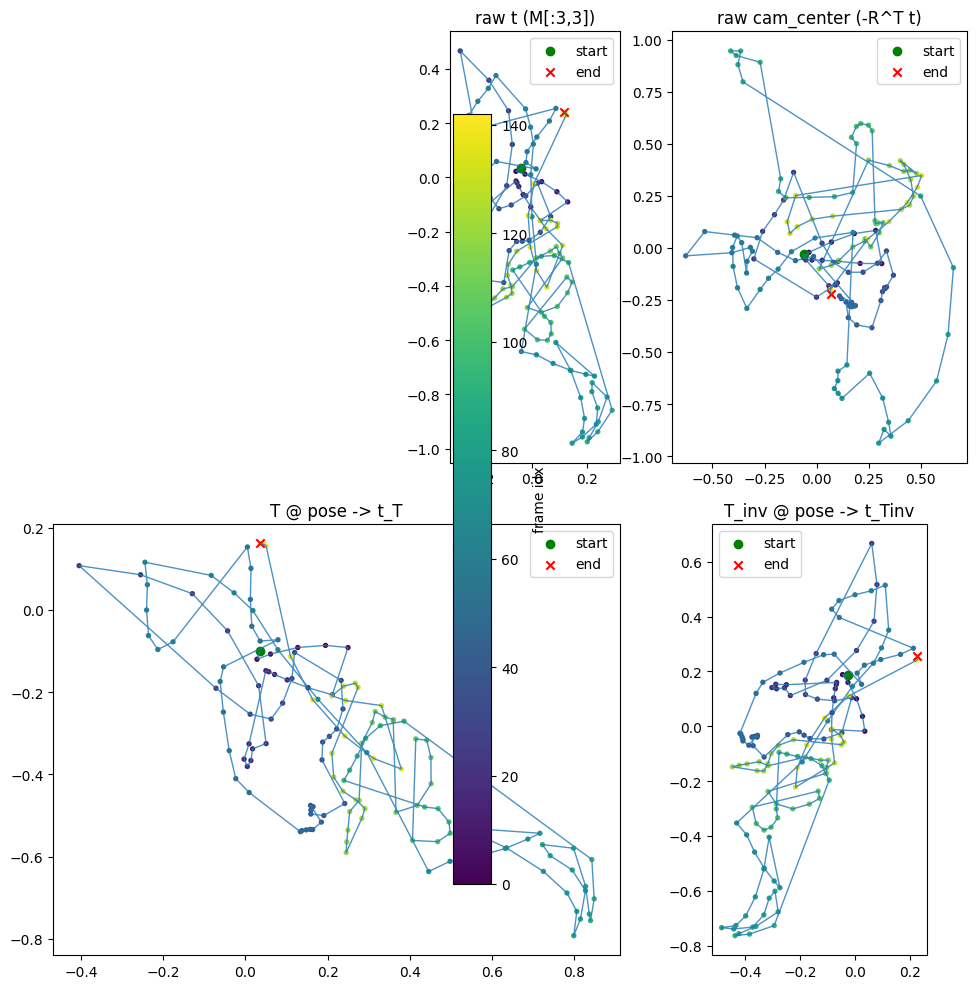


Heuristic suggestion:
range(T)=2.042, range(T_inv)=2.058
 -> ambiguous: ranges comparable. Inspect plots: choose interpretation with physically reasonable trajectory.


In [8]:
# Diagnostic cell - запускай в Jupyter (замени пути)
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from zipfile import ZipFile
import os, sys

# ---- user params: укажи свои пути ----
seq_folder = Path("/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/02b33dfb-be2b-2d54-92d2-cd012b2b3c40/sequence")
meta_json_path = Path("/mnt/external_usb_hdd/6YL/Datasets/3RScan/files/3RScan.json")
meta_index = 1   # ты использовал meta[1]
scan_idx_within_item = 0  # ты использовал item['scans'][0]
# ---------------------------------------

# ---- helpers ----
def mat_from_flat_list(flat16):
    arr = np.array(flat16, dtype=float)
    if arr.size != 16:
        raise ValueError("Expected 16 numbers")
    # 3RScan JSON flattened transforms are column-major -> use order='F'
    M = arr.reshape((4,4), order='F')
    return M

def parse_pose_file(path):
    # robust parsing: support 4x4 text or single-line 16 values
    txt = Path(path).read_text().strip()
    toks = []
    for line in txt.splitlines():
        parts = line.strip().split()
        if len(parts) == 0: continue
        toks.extend(parts)
    vals = [float(x) for x in toks]
    if len(vals) >= 16:
        M = np.array(vals[:16], dtype=float).reshape((4,4))
        return M
    else:
        raise RuntimeError(f"Cannot parse pose file {path}: not enough numbers")

def inv_transform(M):
    R = M[:3,:3]
    t = M[:3,3]
    Rinv = R.T
    tinv = -Rinv @ t
    M_inv = np.eye(4, dtype=M.dtype)
    M_inv[:3,:3] = Rinv
    M_inv[:3,3] = tinv
    return M_inv

def apply_transform(M, pose):
    # returns M @ pose
    return M @ pose

def cam_center_from_pose(M):
    R = M[:3,:3]
    t = M[:3,3]
    return -R.T @ t

# ---- load metadata transform T ----
import json
meta = json.load(open(str(meta_json_path), 'r'))
item = meta[meta_index]
scan_entry = item['scans'][scan_idx_within_item]
scan_transform_flat = scan_entry.get('transform', None)
if scan_transform_flat is None:
    raise RuntimeError("No transform found in scan entry")
T = mat_from_flat_list(scan_transform_flat)
T_inv = inv_transform(T)
print("T translation (from JSON transform):", T[:3,3])
print("T_inv translation:", T_inv[:3,3])
print("det(R) of T:", np.linalg.det(T[:3,:3]))

# ---- load per-frame pose files ----
pose_files = sorted(seq_folder.glob("**/frame-*.pose.txt"))
if len(pose_files) == 0:
    raise RuntimeError(f"No pose files found under {seq_folder}")
print(f"Found {len(pose_files)} pose files, example: {pose_files[0].name}")

poses = []
bad = []
for p in pose_files:
    try:
        M = parse_pose_file(p)
        # if file is written as one-line column-major, you may need to reshape with order='F' instead:
        # try to detect: if bottom row not [0,0,0,1], try reshape(order='F')
        if not np.allclose(M[3,:], [0,0,0,1], atol=1e-6):
            # try column-major interpretation
            vals = np.array([float(x) for x in Path(p).read_text().strip().split()])
            if vals.size >= 16:
                M_alt = vals[:16].reshape((4,4), order='F')
                if np.allclose(M_alt[3,:], [0,0,0,1], atol=1e-6):
                    M = M_alt
        poses.append(M)
    except Exception as e:
        bad.append((p, str(e)))
if bad:
    print("Some pose files failed to parse (showing up to 5):", bad[:5])

poses = np.array(poses)  # shape (N,4,4)
N = poses.shape[0]

# ---- compute candidates ----
t_raw = np.array([poses[i,:3,3] for i in range(N)])
cam_raw = np.array([cam_center_from_pose(poses[i]) for i in range(N)])
# transformed (two hypotheses)
poses_T = np.array([apply_transform(T, poses[i]) for i in range(N)])
t_T = np.array([poses_T[i,:3,3] for i in range(N)])
cam_T = np.array([cam_center_from_pose(poses_T[i]) for i in range(N)])
poses_Tinv = np.array([apply_transform(T_inv, poses[i]) for i in range(N)])
t_Tinv = np.array([poses_Tinv[i,:3,3] for i in range(N)])
cam_Tinv = np.array([cam_center_from_pose(poses_Tinv[i]) for i in range(N)])

# ---- quick stats ----
def stats(name, arr):
    norms = np.linalg.norm(arr, axis=1)
    return f"{name}: n={len(arr)}  norm_min={norms.min():.3f} mean={norms.mean():.3f} max={norms.max():.3f}"
print(stats("t_raw", t_raw))
print(stats("cam_raw", cam_raw))
print(stats("t_T", t_T))
print(stats("cam_T", cam_T))
print(stats("t_Tinv", t_Tinv))
print(stats("cam_Tinv", cam_Tinv))

# print sample frames
print("sample translations (first 5) t_raw:\n", t_raw[:5])
print("sample cam centers (first 5) cam_raw:\n", cam_raw[:5])
print("sample transformed (T) t_T[:5]:\n", t_T[:5])
print("sample transformed (T_inv) t_Tinv[:5]:\n", t_Tinv[:5])

# ---- plotting 2x2: raw vs transformed ----
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0,1,N))
fig, axes = plt.subplots(2,2, figsize=(12,10), sharex=False, sharey=False)
ax = axes.ravel()

def plot_xy(ax, arr, title):
    x = arr[:,0]; y = arr[:,1]
    ax.plot(x, y, '-', linewidth=1, alpha=0.8)
    sc = ax.scatter(x, y, c=np.arange(len(x)), cmap='viridis', s=8)
    ax.scatter(x[0], y[0], c='green', marker='o', label='start')
    ax.scatter(x[-1], y[-1], c='red', marker='x', label='end')
    ax.set_title(title)
    ax.set_aspect('equal', 'box')
    ax.legend()
    return sc

sc0 = plot_xy(ax[0], t_raw, "raw t (M[:3,3])")
sc1 = plot_xy(ax[1], cam_raw, "raw cam_center (-R^T t)")
sc2 = plot_xy(ax[2], t_T, "T @ pose -> t_T")
sc3 = plot_xy(ax[3], t_Tinv, "T_inv @ pose -> t_Tinv")

fig.colorbar(sc0, ax=axes[:,0].tolist(), label='frame idx')
plt.tight_layout()
plt.show()

# ---- heuristic suggestion ----
print("\nHeuristic suggestion:")
# choose which transformed has larger spread (likely correct world coordinates)
range_T = np.linalg.norm(t_T.max(axis=0)-t_T.min(axis=0))
range_Tinv = np.linalg.norm(t_Tinv.max(axis=0)-t_Tinv.min(axis=0))
print(f"range(T)={range_T:.3f}, range(T_inv)={range_Tinv:.3f}")
if range_T > range_Tinv*1.5:
    print(" -> T (as read from JSON) produces larger spread — likely T is rescan->reference and should be used (T@pose).")
elif range_Tinv > range_T*1.5:
    print(" -> inv(T) produces larger spread — likely you should use inv(T) (i.e. T in JSON is reference->rescan).")
else:
    print(" -> ambiguous: ranges comparable. Inspect plots: choose interpretation with physically reasonable trajectory.")

In [9]:
import numpy as np
from pathlib import Path

# ---------- Утилиты для чтения поз ----------
def parse_pose_file(path):
    """
    Robust parse of frame-*.pose.txt
    Accepts:
      - 4 lines of 4 floats (row-major)
      - single-line with 16 floats (attempts row-major, then column-major)
    Returns 4x4 numpy array (row-major regular matrix).
    """
    txt = Path(path).read_text().strip()
    toks = []
    for line in txt.splitlines():
        parts = line.strip().split()
        if len(parts) == 0:
            continue
        toks.extend(parts)
    vals = [float(x) for x in toks]
    if len(vals) < 16:
        raise RuntimeError(f"Pose file {path} contains <16 numbers")
    # try row-major by default
    M = np.array(vals[:16], dtype=float).reshape((4,4))
    # if bottom row isn't [0,0,0,1], try column-major interpretation
    if not np.allclose(M[3,:], [0,0,0,1], atol=1e-6):
        M_alt = np.array(vals[:16], dtype=float).reshape((4,4), order='F')
        if np.allclose(M_alt[3,:], [0,0,0,1], atol=1e-6):
            M = M_alt
    # final sanity: if still bad, still return M but warn
    if not np.allclose(M[3,:], [0,0,0,1], atol=1e-4):
        print(f"Warning: pose {path} bottom row != [0,0,0,1] (got {M[3,:]})")
    return M

def mat_from_flat_list_column_major(flat16):
    """
    Parse flat 16-list from 3RScan JSON (they are column-major).
    """
    arr = np.array(flat16, dtype=float)
    if arr.size != 16:
        raise ValueError("Expected 16 numbers for transform")
    M = arr.reshape((4,4), order='F')
    return M

def inv_transform(M):
    R = M[:3,:3]; t = M[:3,3]
    Rinv = R.T
    tinv = -Rinv @ t
    M_inv = np.eye(4, dtype=M.dtype)
    M_inv[:3,:3] = Rinv
    M_inv[:3,3] = tinv
    return M_inv

# ---------- load_frame_poses: возвращаем dict по frame_idxs ----------
def load_frame_poses(data_dir, scan_id, frame_idxs, type='matrix'):
    """
    frame_idxs: iterable of frame id strings, e.g. ['000000','000001',...]
    Returns dict: frame_idx_str -> 4x4 numpy array (or quat+trans if type requested)
    """
    frame_poses = {}
    seq_folder = Path(data_dir) / scan_id / 'sequence'
    for frame_idx in frame_idxs:
        pose_path = seq_folder / f'frame-{frame_idx}.pose.txt'
        if not pose_path.exists():
            raise FileNotFoundError(f"Pose file not found: {pose_path}")
        M = parse_pose_file(pose_path)
        if type == 'matrix':
            frame_poses[frame_idx] = M
        elif type == 'quat_trans':
            # convert rotation matrix to quaternion (xyzw from scipy) + translation
            from scipy.spatial.transform import Rotation as R
            quat = R.from_matrix(M[:3,:3]).as_quat()   # returns [x,y,z,w]
            trans = M[:3,3]
            frame_poses[frame_idx] = np.concatenate([quat, trans])
        else:
            raise ValueError("Unknown type")
    return frame_poses

# ---------- find_cam_centers: индексация по именам ----------
def find_cam_centers(frame_idxs, frame_poses, pose_format='matrix'):
    """
    frame_idxs: list of frame id strings in desired order
    frame_poses: dict mapping frame_id_str -> 4x4 matrix (as returned by load_frame_poses)
    Returns:
      centers_cam2world: Nx3 array where we assume pose is camera->world and center = t
      centers_world2cam: Nx3 array where we assume pose is world->camera and center = -R^T t
    IMPORTANT: does NOT perform any unit scaling.
    """
    centers_cam2world = []
    centers_world2cam = []
    for fid in frame_idxs:
        if fid not in frame_poses:
            raise KeyError(f"Frame id {fid} not found in frame_poses")
        M = frame_poses[fid]
        if pose_format != 'matrix':
            raise ValueError("Only 'matrix' supported here")
        # candidate A: if M is camera->world, center = t
        t = M[:3,3].astype(float)
        centers_cam2world.append(t)
        # candidate B: if M is world->camera, center = -R^T t
        Rm = M[:3,:3]
        cam_center = -Rm.T @ t
        centers_world2cam.append(cam_center)
    return np.array(centers_cam2world), np.array(centers_world2cam)

In [13]:
# параметры (замени свои пути)
import os

DATA_DIR = "/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes"   # корень scenes
SCAN_ID = "02b33dfb-be2b-2d54-92d2-cd012b2b3c40"
SEQ_DIR = os.path.join(DATA_DIR, SCAN_ID, "sequence")

# 1) собираем frame_idxs (строки) — как у тебя в load_frame_idxs
from glob import glob
frame_files = sorted(glob(os.path.join(SEQ_DIR, "frame-*.pose.txt")))
frame_idxs = [ os.path.basename(p).split('.')[0].split('-')[-1] for p in frame_files ]

# 2) load poses dict корректно
frame_poses = load_frame_poses(data_dir=scans_scenes_dir, scan_id, frame_idxs)
# (если используешь оригинальную структуру, поправь вызов: load_frame_poses(data_dir=scans_scenes_dir, scan_id, frame_idxs) )

# 3) compute centers
centers_cam2world, centers_world2cam = find_cam_centers(frame_idxs, frame_poses)

# 4) quick checks
print("Num frames:", len(frame_idxs))
print("centers_cam2world stats:", np.linalg.norm(centers_cam2world, axis=1).min(), np.linalg.norm(centers_cam2world, axis=1).max())
print("centers_world2cam stats:", np.linalg.norm(centers_world2cam, axis=1).min(), np.linalg.norm(centers_world2cam, axis=1).max())

# 5) plot XY (2D)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.plot(centers_cam2world[:,0], centers_cam2world[:,1], '-o', markersize=2, label='t (camera->world)')
plt.plot(centers_world2cam[:,0], centers_world2cam[:,1], '-x', markersize=2, label='-R^T t (world->camera)')
plt.legend(); plt.axis('equal'); plt.title("Compare candidate centers (XY)")
plt.show()

SyntaxError: positional argument follows keyword argument (1097815025.py, line 14)

In [2]:
# Notebook cell: paste and run in Jupyter / Colab
# Dependencies: numpy, matplotlib (обычно предустановлены в notebooks)

import os
import glob
import re
from typing import List, Tuple, Dict, Any
import numpy as np
import matplotlib.pyplot as plt

def read_pose_file(pose_path: str) -> np.ndarray:
    """Read pose file and return 4x4 numpy array (supports 16 numbers in one line or 4x4 layout)."""
    try:
        arr = np.loadtxt(pose_path)
    except Exception:
        arr = np.genfromtxt(pose_path)
    arr = np.array(arr).flatten()
    if arr.size != 16:
        raise ValueError(f"File {pose_path} doesn't contain 16 numbers (found {arr.size}).")
    return arr.reshape(4, 4).astype(np.float64)

def extract_frame_index_from_name(filename: str) -> Any:
    """Extract numeric index from names like 'frame-000123.pose.txt'; fallback to basename."""
    base = os.path.basename(filename)
    m = re.search(r'frame-(\d+)\.pose', base)
    if m:
        return int(m.group(1))
    m2 = re.search(r'(\d+)\.pose', base)
    if m2:
        return int(m2.group(1))
    return base

def compute_camera_center_from_T(T: np.ndarray, convention: str = 'cam2world') -> np.ndarray:
    """
    Return 3D camera center in world coords.
    convention:
      - 'cam2world' (default): T stores cam->world, center = T[:3,3]
      - 'world2cam': T stores world->cam, center = -R^T t
    """
    if T.shape != (4,4):
        raise ValueError("T must be 4x4")
    Rmat = T[:3,:3]
    t = T[:3,3]
    if convention == 'cam2world':
        return t.copy()
    elif convention == 'world2cam':
        return - Rmat.T.dot(t)
    else:
        raise ValueError("convention must be 'cam2world' or 'world2cam'")

def load_camera_centers_from_folder(folder: str, pose_glob_pattern: str = 'frame-*.pose.txt',
                                    recursive: bool = False, convention: str = 'cam2world') -> Tuple[List[Any], np.ndarray]:
    """
    Scan a folder for pose files and return (indices_sorted, centers_sorted Nx3).
    If recursive=True, search subfolders too.
    convention: 'cam2world'|'world2cam'|'auto'
    When 'auto', picks convention with smaller spatial spread (simple heuristic).
    """
    search = os.path.join(folder, pose_glob_pattern)
    files = glob.glob(search)
    if not files and recursive:
        files = glob.glob(os.path.join(folder, '**', os.path.basename(pose_glob_pattern)), recursive=True)
    if not files:
        files = glob.glob(os.path.join(folder, '**', '*.pose.txt'), recursive=recursive)
    files = sorted(files)

    indices = []
    Ts = []
    for f in files:
        try:
            T = read_pose_file(f)
            idx = extract_frame_index_from_name(f)
            indices.append(idx)
            Ts.append((f, T))
        except Exception as e:
            print(f"Warning: couldn't read {f}: {e}")

    if not Ts:
        return [], np.zeros((0,3), dtype=np.float64)

    chosen = convention
    if convention == 'auto':
        cand_a = []
        cand_b = []
        for _, T in Ts:
            t = T[:3,3]
            Rmat = T[:3,:3]
            cand_a.append(t)
            cand_b.append(-Rmat.T.dot(t))
        cand_a = np.array(cand_a)
        cand_b = np.array(cand_b)
        dia_a = np.max(np.linalg.norm(cand_a - cand_a.mean(axis=0), axis=1))
        dia_b = np.max(np.linalg.norm(cand_b - cand_b.mean(axis=0), axis=1))
        chosen = 'cam2world' if dia_a <= dia_b else 'world2cam'
        print(f"[auto-detect] chosen convention = {chosen} (dia_a={dia_a:.4f}, dia_b={dia_b:.4f})")

    centers = [compute_camera_center_from_T(T, convention=chosen) for _, T in Ts]

    # sort by indices if numeric, else by string
    try:
        order = np.argsort(np.array(indices, dtype=np.int64))
    except Exception:
        order = np.argsort(np.array([str(i) for i in indices]))
    indices_sorted = [indices[i] for i in order]
    centers_sorted = np.array(centers)[order]
    return indices_sorted, centers_sorted

def plot_camera_tracks_notebook(folders: List[str], labels: List[str] = None,
                       plane: Tuple[str,str] = ('x','z'),
                       pose_glob_pattern: str = 'frame-*.pose.txt',
                       recursive: bool = False,
                       convention: str = 'cam2world',
                       annotate_every: int = 0,
                       marker_every: int = 1,
                       figsize: Tuple[int,int] = (10,8),
                       save_path: str = None,
                       show: bool = True) -> Dict[str, Any]:
    """
    Notebook-friendly plotting of camera tracks.
    plane: ('x','z') by default -> ground plane (drop height).
    annotate_every: annotate index every N points (0 = off)
    marker_every: mark points every N samples (set >1 to reduce marker clutter)
    convention: 'cam2world'|'world2cam'|'auto'
    Returns: dict folder -> {'indices': [...], 'centers': Nx3}
    """
    axis_map = {'x':0, 'y':1, 'z':2}
    if plane[0] not in axis_map or plane[1] not in axis_map:
        raise ValueError("plane must be tuple of ('x','y','z')")
    ix, iy = axis_map[plane[0]], axis_map[plane[1]]

    if isinstance(folders, str):
        folders = [folders]
    if labels is None:
        labels = [os.path.basename(f.rstrip('/\\')) or f for f in folders]
    if len(labels) != len(folders):
        raise ValueError("len(labels) must match len(folders)")

    plt.figure(figsize=figsize)
    ax = plt.gca()

    results = {}
    for folder, label in zip(folders, labels):
        idxs, centers = load_camera_centers_from_folder(folder, pose_glob_pattern=pose_glob_pattern,
                                                        recursive=recursive, convention=convention)
        if centers.shape[0] == 0:
            print(f"Warning: no pose files found in {folder}. Skipping.")
            continue
        xs = centers[:, ix]
        ys = centers[:, iy]
        ax.plot(xs, ys, marker='o', label=label, markevery=marker_every)
        ax.scatter([xs[0]], [ys[0]], marker='s', zorder=5)   # start
        ax.scatter([xs[-1]], [ys[-1]], marker='*', zorder=5) # end
        if annotate_every and annotate_every > 0:
            for i in range(0, len(xs), annotate_every):
                ax.text(xs[i], ys[i], str(idxs[i]), fontsize=7, alpha=0.8)
        results[folder] = {'indices': idxs, 'centers': centers}

    ax.set_aspect('equal', adjustable='datalim')
    ax.grid(True)
    ax.legend()
    ax.set_xlabel(f"{plane[0]} (world units)")
    ax.set_ylabel(f"{plane[1]} (world units)")
    ax.set_title("Camera tracks (projected to 2D)")

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=200)
        print(f"Saved figure to {save_path}")
    if show:
        plt.show()
    else:
        plt.close()

    return results

# ------------------ Demo (optional) ------------------
# Uncomment or run as-is to see a demo (it will create demo folders under /mnt/data)
if __name__ == "__main__" and False:
    demo_base = '/mnt/data/demo_pose_tracks'
    os.makedirs(demo_base, exist_ok=True)

    def make_demo_folder(name, translations):
        folder = os.path.join(demo_base, name)
        os.makedirs(folder, exist_ok=True)
        for i, t in enumerate(translations):
            T = np.eye(4)
            T[:3,3] = np.array(t)
            fname = os.path.join(folder, f"frame-{i:06d}.pose.txt")
            np.savetxt(fname, T, fmt="%.6f")
        return folder

    f1 = make_demo_folder('walk1', [(i*0.05, 0.0, i*0.02) for i in range(30)])
    f2 = make_demo_folder('walk2', [(0.5 + i*0.03, 0.0, -0.02*i + 0.1*np.sin(i/3.0)) for i in range(30)])

    tracks = plot_camera_tracks_notebook([f1, f2], labels=['demo_walk1', 'demo_walk2'],
                                         plane=('x','z'), save_path='/mnt/data/demo_tracks_nb.png', show=True)

    print("Returned tracks summary:")
    for k,v in tracks.items():
        print(k, "frames:", len(v['indices']), "first_center:", v['centers'][0])
    print("Saved demo image: /mnt/data/demo_tracks_nb.png")

In [4]:
# ---------- Функции для работы с изображениями ----------
def get_image_path(scene_folder, frame_index, ext='.color.jpg', digits=6):
    """
    Возвращает путь к изображению кадра.
    Формат: frame-{frame_index:0{digits}d}{ext}
    """
    filename = f"frame-{frame_index:0{digits}d}{ext}"
    return os.path.join(scene_folder,'sequence', filename)

def display_query_and_neighbors(query_image_path, neighbor_paths, distances=None, max_cols=4):
    """
    Отображает изображение запроса и найденные похожие изображения.
    
    Параметры:
        query_image_path (str): путь к изображению запроса
        neighbor_paths (list): список путей к изображениям соседей
        distances (list): список расстояний (для подписей)
        max_cols (int): максимальное количество изображений в строке
    """
    n_neighbors = len(neighbor_paths)
    total = 1 + n_neighbors
    cols = min(max_cols, total)
    rows = (total + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    # Приводим axes к плоскому списку для удобства индексации
    if rows == 1:
        axes = [axes] if cols == 1 else axes
    else:
        axes = axes.flatten()
    
    # Запрос
    img_query = Image.open(query_image_path)
    axes[0].imshow(img_query)
    axes[0].set_title("Query")
    axes[0].axis('off')
    
    # Соседи
    for i, path in enumerate(neighbor_paths):
        ax = axes[i+1]
        img = Image.open(path)
        ax.imshow(img)
        title = f"Neighbor {i+1}"
        if distances is not None and i < len(distances):
            title += f"\nd={distances[i]:.2f}m"
        ax.set_title(title)
        ax.axis('off')
    
    # Скрыть лишние оси
    for j in range(total, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()


In [23]:
def transform_points(points_3d, transform_matrix):
    """
    points_3d: массив формы (N, 3) с координатами (x, y, z)
    transform_matrix: матрица 4x4, задающая преобразование (R|t)
    Возвращает преобразованные точки в той же форме (N, 3)
    """
    # Добавляем единичную координату (N, 4)
    ones = np.ones((points_3d.shape[0], 1))
    points_h = np.hstack([points_3d, ones])  # (N, 4)
    # Умножение на матрицу (4x4) слева: points_transformed_h = (M @ points_h.T).T
    points_transformed_h = (transform_matrix @ points_h.T).T  # (N, 4)
    # Возвращаем первые три координаты
    return points_transformed_h[:, :3]


from scipy.spatial import KDTree
import numpy as np

def find_poses_in_radius(results, track1_key, track2_key, frame_index, radius, transform_matrix=None):
    """
    Находит все кадры во втором треке, чьи центры находятся в пределах radius метров
    от центра заданного кадра из первого трека.

    Параметры:
        results (dict): словарь, возвращаемый plot_camera_tracks_notebook
        track1_key (str): ключ первого трека (путь к папке)
        track2_key (str): ключ второго трека
        frame_index (int): номер кадра в первом треке (значение из списка indices)
        radius (float): радиус поиска в метрах
        transform_matrix (np.array): матрица 4x4 для преобразования точек второго трека
                                      в систему первого трека (если нужно)

    Возвращает:
        distances (np.ndarray): массив расстояний до найденных кадров (отсортирован по возрастанию)
        frame_indices_track2 (list): соответствующие номера кадров во втором треке
    """
    if track1_key not in results or track2_key not in results:
        raise KeyError("Указанные ключи треков отсутствуют в results")
    
    data1 = results[track1_key]
    data2 = results[track2_key]
    
    # Находим позицию запрашиваемого кадра в первом треке
    try:
        pos1_idx = data1['indices'].index(frame_index)
    except ValueError:
        raise ValueError(f"Кадр {frame_index} не найден в первом треке")
    
    query_point = data1['centers'][pos1_idx]
    
    # Центры второго трека (с преобразованием, если задано)
    centers2 = data2['centers']
    if transform_matrix is not None:
        centers2 = transform_points(centers2, transform_matrix)  # функция определена ранее
    
    # Построение KD-дерева
    tree = KDTree(centers2)
    idxs = tree.query_ball_point(query_point, r=radius)  # список индексов в радиусе
    
    if not idxs:
        return np.array([]), []
    
    # Вычисляем расстояния до найденных точек
    distances = [np.linalg.norm(centers2[i] - query_point) for i in idxs]
    
    # Сортируем по расстоянию
    sorted_idx = np.argsort(distances)
    idxs_sorted = [idxs[i] for i in sorted_idx]
    distances_sorted = np.array(distances)[sorted_idx]
    
    # Номера кадров
    frame_indices = [data2['indices'][i] for i in idxs_sorted]
    
    return distances_sorted, frame_indices

def plot_poses_in_radius(results, track1_key, track2_key, frame_index, radius,
                         transform_matrix=None, plane=('x','z'), figsize=(10,8),
                         save_path=None, max_to_show=None):
    """
    Строит график с траекториями обоих треков, выделяет точку запроса и все кадры
    из второго трека, попавшие в заданный радиус.

    Параметры:
        results, track1_key, track2_key, frame_index, radius, transform_matrix — см. find_poses_in_radius
        plane (tuple): проекция ('x','z') по умолчанию
        figsize (tuple): размер графика
        save_path (str): если указано, сохраняет рисунок
        max_to_show (int): максимальное количество отображаемых соседей (если нужно ограничить)
    """
    distances, neighbors = find_poses_in_radius(results, track1_key, track2_key,
                                                frame_index, radius, transform_matrix)
    
    if len(distances) == 0:
        print(f"В радиусе {radius} м не найдено ни одного кадра.")
        return
    
    if max_to_show is not None:
        # Показываем только первые max_to_show по расстоянию
        distances = distances[:max_to_show]
        neighbors = neighbors[:max_to_show]
    
    axis_map = {'x':0, 'y':1, 'z':2}
    ix, iy = axis_map[plane[0]], axis_map[plane[1]]
    
    data1 = results[track1_key]
    data2 = results[track2_key]
    
    pos1_idx = data1['indices'].index(frame_index)
    pos1 = data1['centers'][pos1_idx]
    
    # Преобразованные центры второго трека для визуализации
    centers2 = data2['centers']
    if transform_matrix is not None:
        centers2 = transform_points(centers2, transform_matrix)
    
    plt.figure(figsize=figsize)
    
    # Рисуем оба трека
    for key, label in zip([track1_key, track2_key], ['Track1', 'Track2']):
        centers = results[key]['centers']
        if key == track2_key and transform_matrix is not None:
            centers = centers2
        xs = centers[:, ix]
        ys = centers[:, iy]
        plt.plot(xs, ys, '-o', label=label, markersize=3, alpha=0.6)
    
    # Точка запроса
    plt.scatter(pos1[ix], pos1[iy], color='red', s=150, marker='s',
                label=f'Запрос: кадр {frame_index}', zorder=5)
    
    # Рисуем окружность радиуса
    circle = plt.Circle((pos1[ix], pos1[iy]), radius, color='red', fill=False, linestyle='--', alpha=0.7)
    plt.gca().add_patch(circle)
    
    # Ближайшие соседи в радиусе
    for i, idx in enumerate([data2['indices'].index(n) for n in neighbors]):
        pt = centers2[idx]
        plt.scatter(pt[ix], pt[iy], color='green', s=80, marker='*',
                    label='В радиусе' if i==0 else '', zorder=5)
        plt.annotate(str(neighbors[i]), (pt[ix], pt[iy]),
                     textcoords="offset points", xytext=(5,5), fontsize=8)
    
    plt.xlabel(plane[0])
    plt.ylabel(plane[1])
    plt.title(f"Кадры из Track2 в радиусе {radius} м от кадра {frame_index}")
    plt.grid(True)
    plt.legend()
    plt.axis('equal')
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    # Вывод информации
    print(f"Найдено кадров: {len(distances)}")
    for i, (d, f) in enumerate(zip(distances, neighbors)):
        print(f"{i+1}: кадр {f}, расстояние {d:.3f} м")

# ---------- Основные функции для пользователя ----------
def show_similar_images(results, track1_key, track2_key, frame_index, k=5,
                        transform_matrix=None, digits=6, ext='.color.jpg'):
    """
    Находит k ближайших кадров из второго трека к заданному кадру первого трека
    и показывает изображения.
    """
    distances, neighbor_indices = find_nearest_poses_with_transform(
        results, track1_key, track2_key, frame_index, transform_matrix, k
    )
    
    query_path = get_image_path(track1_key, frame_index, ext, digits)
    neighbor_paths = [get_image_path(track2_key, idx, ext, digits) for idx in neighbor_indices]
    
    # Проверка существования файлов
    if not os.path.exists(query_path):
        print(f"Предупреждение: файл запроса не найден: {query_path}")
        return
    
    missing = [p for p in neighbor_paths if not os.path.exists(p)]
    if missing:
        print(f"Предупреждение: отсутствуют файлы соседей: {missing}")
    
    display_query_and_neighbors(query_path, neighbor_paths, distances)

def show_images_in_radius(results, track1_key, track2_key, frame_index, radius,
                          transform_matrix=None, digits=6, ext='.color.jpg', max_to_show=None):
    """
    Показывает все изображения из второго трека, попавшие в заданный радиус.
    Если max_to_show задано, отображается не более этого количества (ближайшие).
    """
    distances, neighbor_indices = find_poses_in_radius(
        results, track1_key, track2_key, frame_index, radius, transform_matrix
    )
    
    if len(distances) == 0:
        print(f"В радиусе {radius} м нет кадров.")
        return
    
    if max_to_show is not None:
        distances = distances[:max_to_show]
        neighbor_indices = neighbor_indices[:max_to_show]
    
    query_path = get_image_path(track1_key, frame_index, ext, digits)
    neighbor_paths = [get_image_path(track2_key, idx, ext, digits) for idx in neighbor_indices]
    
    if not os.path.exists(query_path):
        print(f"Предупреждение: файл запроса не найден: {query_path}")
        return
    
    display_query_and_neighbors(query_path, neighbor_paths, distances)

[auto-detect] chosen convention = cam2world (dia_a=1.3111, dia_b=1.7683)
[auto-detect] chosen convention = cam2world (dia_a=1.2998, dia_b=1.7583)
Saved figure to tracks.png


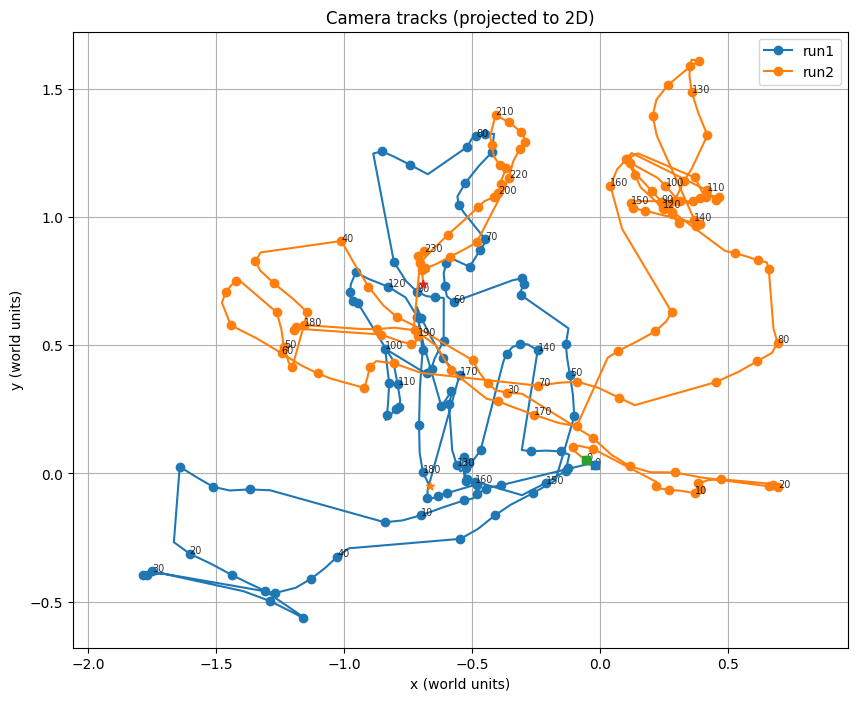

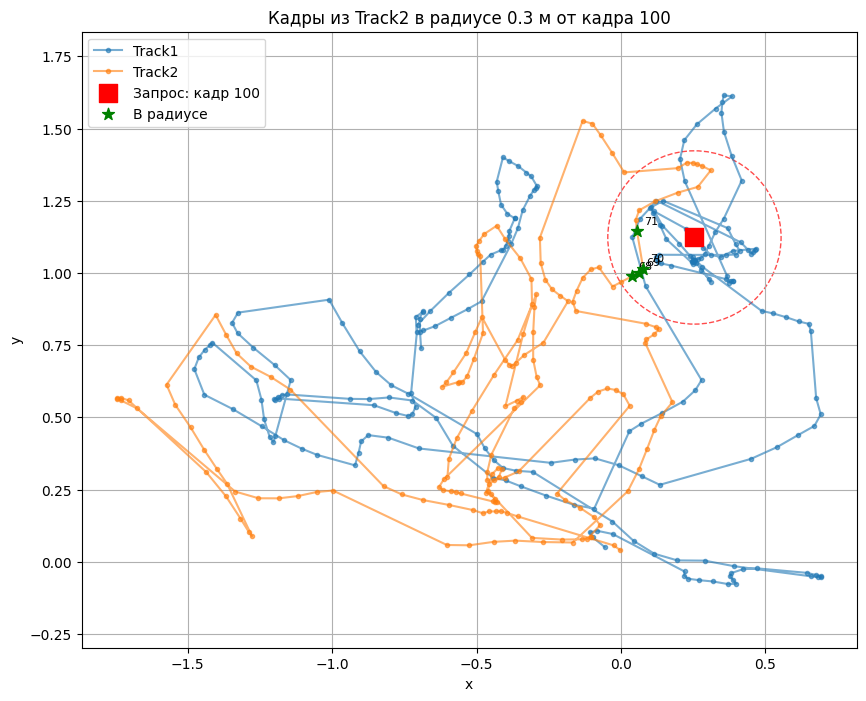

Найдено кадров: 4
1: кадр 70, расстояние 0.222 м
2: кадр 69, расстояние 0.237 м
3: кадр 68, расстояние 0.265 м
4: кадр 71, расстояние 0.296 м


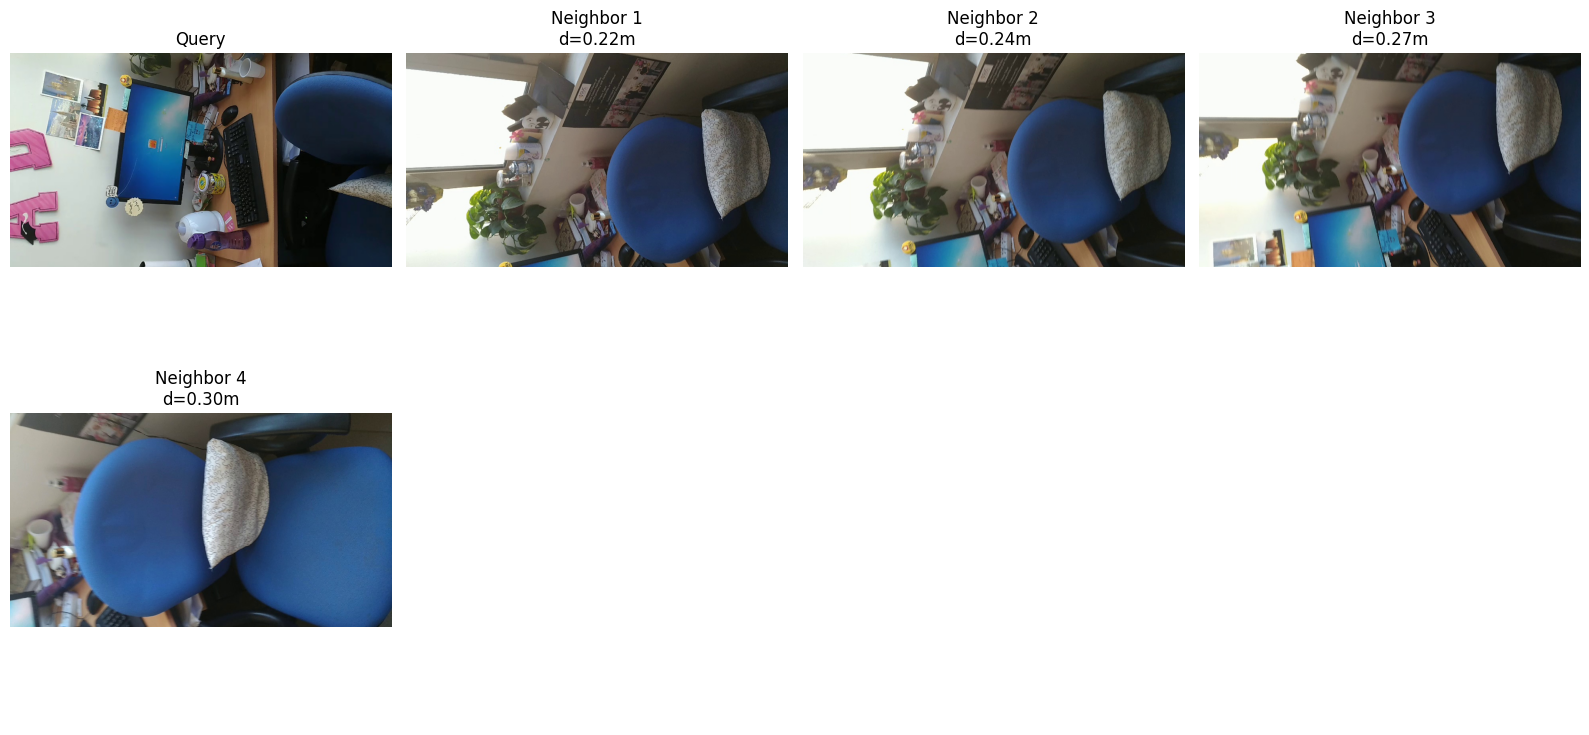

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.spatial import KDTree

matrix_data = [
          0.86197835206985474,
          0.50653976202011108,
          0.020271344110369682,
          0,
          -0.50639784336090088,
          0.86221671104431152,
          -0.011990923434495926,
          0,
          -0.023552171885967255,
          0.000070551417593378574,
          0.99972271919250488,
          0,
          -0.064294837415218353,
          -0.23404276371002197,
          -0.044750727713108063,
          1
]
#matrix_data = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]
M_Track2_to_Track1 = np.array(matrix_data).reshape(4, 4)

track2 = "/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/0958224e-e2c2-2de1-943b-38e36345e2e7"
track1 = "/mnt/external_usb_hdd/6YL/Datasets/3RScan/scenes/09582250-e2c2-2de1-9541-3efcbdc2dca4"

frame_id = 100

# Предположим, что вы уже построили треки и сохранили результат в переменную tracks
tracks = plot_camera_tracks_notebook([track1,
                                      track2],
                                     labels=['run1','run2'],
                                     plane=('x','y', 'z'),
                                     convention='auto',
                                     annotate_every=10,
                                     marker_every=2,
                                     save_path='tracks.png')

# Теперь найдём 3 ближайших кадра во втором треке к кадру номер 15 из первого трека
distances, neighbors = find_poses_in_radius(tracks,
                                          track1_key=track1,
                                          track2_key=track2,
                                          frame_index=frame_id,
                                          radius=0.5,
                                          transform_matrix=M_Track2_to_Track1)

# Визуализируем результат
plot_poses_in_radius(tracks,
                   track1_key=track1,
                   track2_key=track2,
                   frame_index=frame_id,
                   radius=0.3,
                   transform_matrix=M_Track2_to_Track1,
                   plane=('x','y'),
                   save_path='nearest_poses.png',
                   max_to_show=20)


show_images_in_radius(tracks,
                      track1,
                      track2,
                      frame_index=frame_id,
                      radius=0.3,
                      transform_matrix=M_Track2_to_Track1,
                      max_to_show=20)